<a href="https://colab.research.google.com/github/ydgbii/week13_lab/blob/main/ML_Lab_Multiclass_Logistic_Regression_OvA_vs_OvO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-class Logistic Regression: One-vs-All vs One-vs-One Approaches**

### Learning Objectives
By the end of this lab, you will be able to:

- Recap binary logistic regression and its loss function.
- Explain why multi-class strategies are required for logistic regression.
- Implement **One-vs-Rest (OvR)** and **One-vs-One (OvO)** using scikit-learn.
- Compare OvR and OvO using the Iris dataset.
- Interpret confusion matrices, class-wise metrics, and decision boundaries.
- Analyze trade-offs: number of classifiers, computational cost, and robustness.


## 1) Introduction

### Binary Logistic Regression Recap
For binary classification, logistic regression models the probability of class 1.

---

### Why Multi-class Strategies?
Binary logistic regression directly handles only **two classes**.  
For datasets with \(K>2\) classes (like Iris with 3 species), we use decomposition strategies:

---

### One-vs-All (OvA / OvR)
- Train **K** binary classifiers.
- Classifier \(k\): class \(k\) vs all other classes.
- Final class = classifier with highest probability score.

**For Iris (K=3):** train 3 classifiers.

**Pros**
- Fewer models than OvO when K is large.
- Easy to implement and scale.
- Works well for many practical tasks.

**Cons**
- Each classifier sees potentially imbalanced labels (one class vs many).
- Boundary quality can suffer when classes overlap heavily.

---

### One-vs-One (OvO)
- Train one classifier for every pair of classes.
- Number of classifiers:

K(K-1)/2

- Final class often selected by majority voting among pairwise models.

**For Iris (K=3):** train 3 classifiers (class pairs: 0-1, 0-2, 1-2).

**Pros**
- Each model solves a simpler 2-class problem.
- Can work better when pairwise boundaries are clean.

**Cons**
- Number of models grows quadratically in \(K\).
- Prediction logic (voting/tie-breaking) is more involved.

---

### When to Prefer Which?
- **Use OvA** when:
  - \(K\) is moderate/large and efficiency matters.
  - You want simpler deployment.
- **Use OvO** when:
  - Pairwise separation is meaningful.
  - You can afford more models and want potentially stronger discrimination.


## 2) Tutorial Section – Step-by-Step Example

In this guided section, we will:

1. Load and explore Iris data.
2. Preprocess with train-test split and standardization.
3. Train scikit-learn Logistic Regression using OvR.
4. Train scikit-learn One-vs-One strategy.
5. Evaluate and compare both approaches.
6. Visualize decision boundaries and probability heatmaps.
7. Compare outcomes in a final summary table.


In [2]:
# Core numerical and data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Timing utility for training-time comparison
import time

# Sklearn utilities used in this lab
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC


# Reproducibility and plot style
np.random.seed(42)
sns.set(style="whitegrid", context="notebook")


### Step 1: Load and Explore the Iris Dataset

We will load Iris data from `sklearn.datasets`, create a DataFrame, and inspect:
- feature columns,
- class names,
- basic shape/statistics.


In [3]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Build a DataFrame for easy exploration and plotting
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map({i: name for i, name in enumerate(class_names)})

print("Feature names:", feature_names)
print("Class names:", class_names)
print("Dataset shape:", X.shape)

display(df.head())
display(df.describe())


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


/tmp/ipykernel_5839/2062526599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="species", palette="Set2")


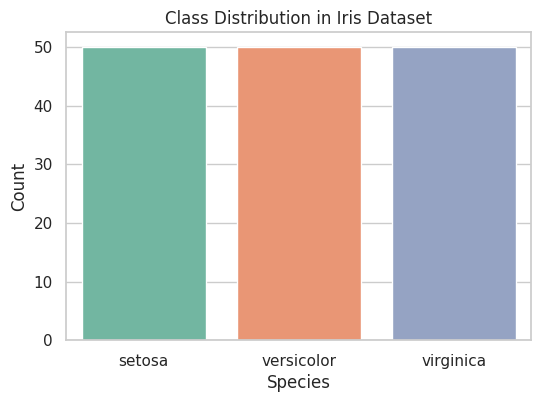

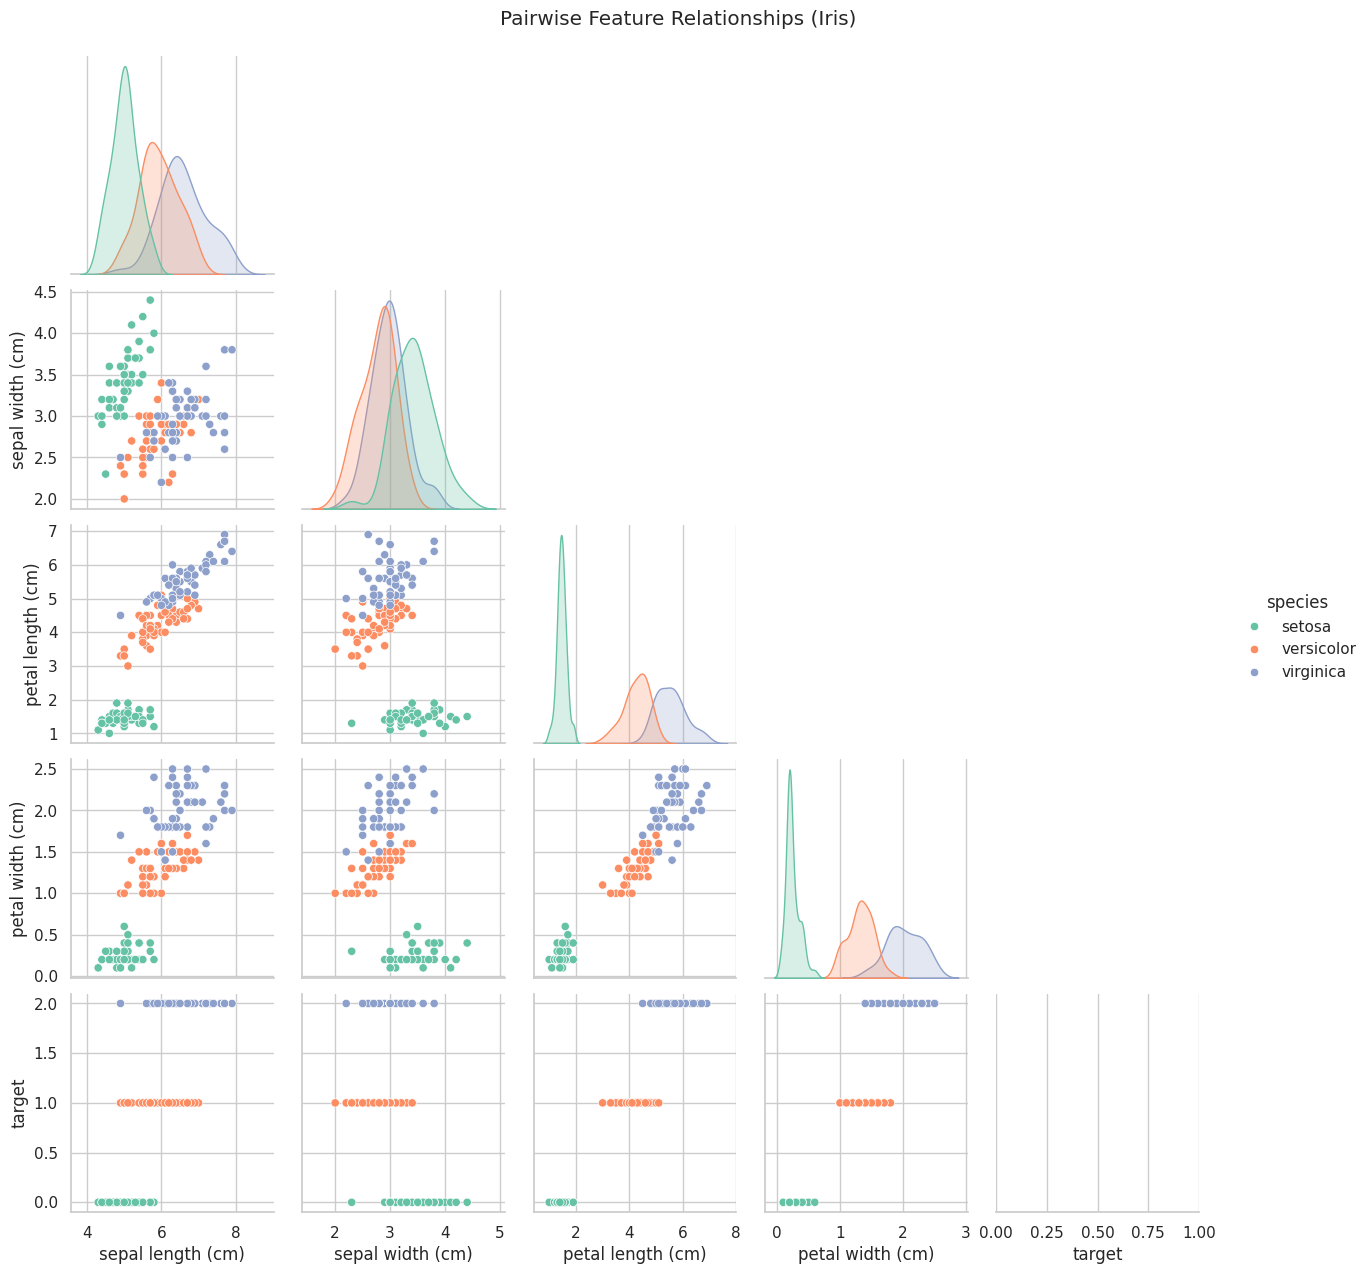

In [4]:
# Visualize class distribution to confirm balanced classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species", palette="Set2")
plt.title("Class Distribution in Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Pairplot gives an intuitive view of pairwise feature separability
sns.pairplot(df, hue="species", corner=True, diag_kind="kde", palette="Set2")
plt.suptitle("Pairwise Feature Relationships (Iris)", y=1.02)
plt.show()


### Step 2: Preprocessing (Train-Test Split + Standardization)

We split data into:
- **80% training**
- **20% testing**

with `random_state=42` and stratification to preserve class proportions.

Then we standardize features so gradient descent behaves more stably.


In [5]:
# Create deterministic train/test indices once for consistent comparisons
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Full-feature sets (4D) for quantitative evaluation
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Two-feature sets (first two features) for 2D visualization
X2_train, X2_test = X_train[:, :2], X_test[:, :2]

# Standardize full feature space
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

# Standardize 2D feature space (for plots)
scaler_2d = StandardScaler()
X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

print("Train shape (4D):", X_train_scaled.shape)
print("Test shape  (4D):", X_test_scaled.shape)
print("Train shape (2D):", X2_train_scaled.shape)
print("Test shape  (2D):", X2_test_scaled.shape)


Train shape (4D): (120, 4)
Test shape  (4D): (30, 4)
Train shape (2D): (120, 2)
Test shape  (2D): (30, 2)


### Step 3: Implement OvR and OvO using scikit-learn

In this version of the lab, we use reliable built-in implementations:

- **OvR (One-vs-Rest):** `LogisticRegression(multi_class='ovr')`
- **OvO (One-vs-One):** `OneVsOneClassifier(LogisticRegression(...))`

This keeps the focus on understanding strategy differences, model behavior, and evaluation.


In [6]:
# We define a small helper function to print evaluation results consistently.
def evaluate_model(name, y_true, y_pred):
    print(f"{name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"\n{name} Classification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))


### Step 4: Train OvR and OvO Models

Now we train both strategies directly using scikit-learn:

- **OvR** with `LogisticRegression(multi_class='ovr')`
- **OvO** with `OneVsOneClassifier(LogisticRegression(...))`

Both models use the same training/test splits for fair comparison.


In [7]:
# Create a common base estimator for reproducibility and consistency.
base_lr = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# OvR model (One-vs-Rest)
ovr_model = LogisticRegression(
    multi_class="ovr",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# OvO model (One-vs-One)
ovo_model = OneVsOneClassifier(base_lr)


### Step 5: Train and Evaluate OvR vs OvO (4 Features)

We now train both strategies on standardized 4D features and evaluate:

- Accuracy
- Confusion matrix
- Classification report (precision, recall, F1)

We also record training time for fair comparison.


In [8]:
# Train OvR model
start_ovr = time.perf_counter()
ovr_model.fit(X_train_scaled, y_train)
ovr_train_time = time.perf_counter() - start_ovr

# Predict with OvR
y_pred_ovr = ovr_model.predict(X_test_scaled)
ovr_accuracy = accuracy_score(y_test, y_pred_ovr)

# Train OvO model
start_ovo = time.perf_counter()
ovo_model.fit(X_train_scaled, y_train)
ovo_train_time = time.perf_counter() - start_ovo

# Predict with OvO
y_pred_ovo = ovo_model.predict(X_test_scaled)
ovo_accuracy = accuracy_score(y_test, y_pred_ovo)

print(f"OvR Accuracy: {ovr_accuracy:.4f}")
print(f"OvO Accuracy: {ovo_accuracy:.4f}")
print(f"OvR Training Time (s): {ovr_train_time:.4f}")
print(f"OvO Training Time (s): {ovo_train_time:.4f}")


OvR Accuracy: 0.9000
OvO Accuracy: 0.9667
OvR Training Time (s): 0.0296
OvO Training Time (s): 0.0368


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


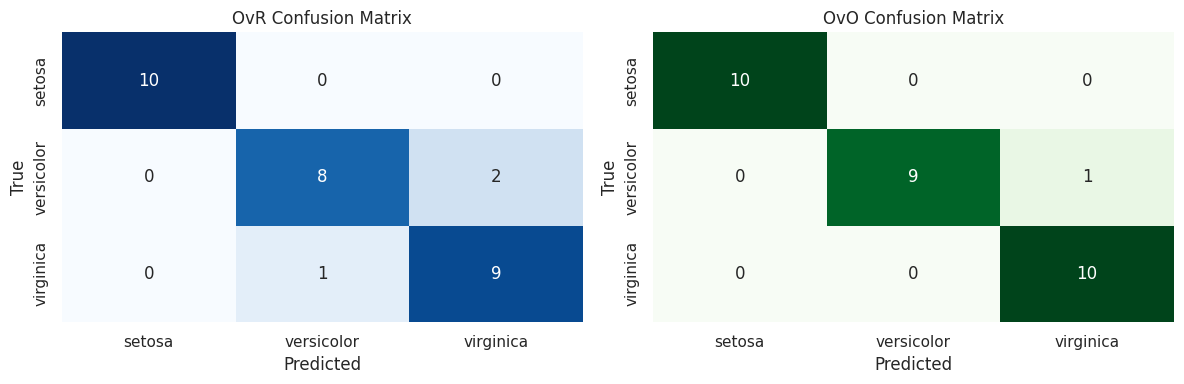

OvR Accuracy: 0.9000

OvR Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

----------------------------------------------------------------------
OvO Accuracy: 0.9667

OvO Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [9]:
# Compute confusion matrices
cm_ovr = confusion_matrix(y_test, y_pred_ovr)
cm_ovo = confusion_matrix(y_test, y_pred_ovo)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm_ovr, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=class_names, yticklabels=class_names, ax=axes[0]
)
axes[0].set_title("OvR Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_ovo, annot=True, fmt="d", cmap="Greens", cbar=False,
    xticklabels=class_names, yticklabels=class_names, ax=axes[1]
)
axes[1].set_title("OvO Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

# Detailed text metrics
evaluate_model("OvR", y_test, y_pred_ovr)
print("-" * 70)
evaluate_model("OvO", y_test, y_pred_ovo)


### Step 6: Visualizations

To make decision regions easy to visualize, we train separate OvR/OvO models on the first two standardized features only.

We will plot:
1. **Decision boundaries** (OvR vs OvO)
2. **OvR probability heatmaps** (one per class)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


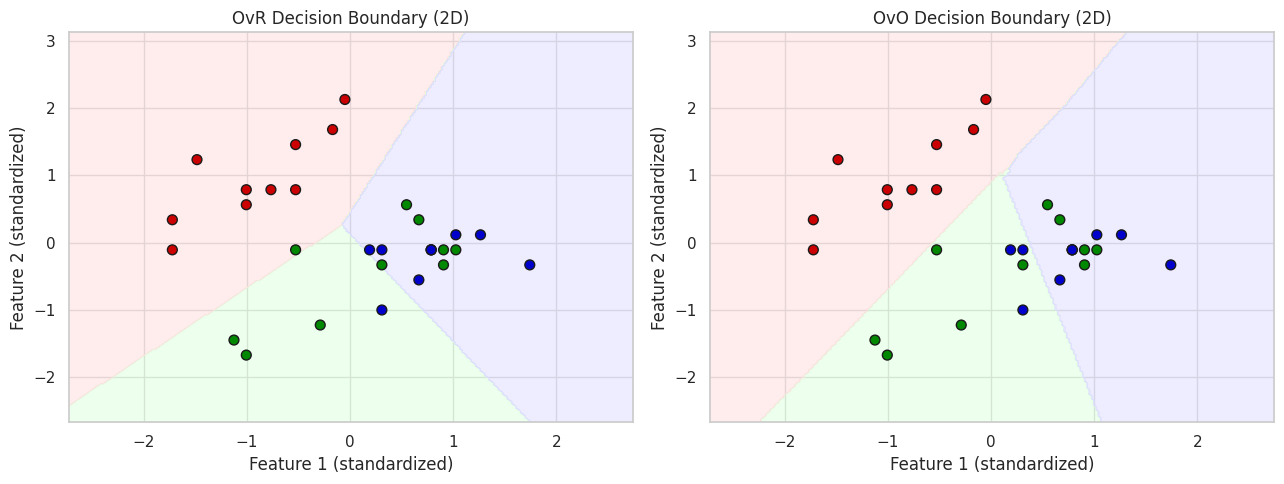

In [10]:
# 2D versions of scikit-learn models for boundary visualization
ovr_2d = LogisticRegression(
    multi_class="ovr",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
).fit(X2_train_scaled, y_train)

ovo_2d = OneVsOneClassifier(
    LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
).fit(X2_train_scaled, y_train)

def plot_decision_boundary(model, X_plot, y_plot, title):
    x_min, x_max = X_plot[:, 0].min() - 1.0, X_plot[:, 0].max() + 1.0
    y_min, y_max = X_plot[:, 1].min() - 1.0, X_plot[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    cmap_light = ListedColormap(["#FFDDDD", "#DDFFDD", "#DDDDFF"])
    cmap_bold = ListedColormap(["#CC0000", "#008800", "#0000CC"])

    plt.contourf(xx, yy, zz, alpha=0.5, cmap=cmap_light)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=cmap_bold, edgecolor="k", s=50)
    plt.title(title)
    plt.xlabel("Feature 1 (standardized)")
    plt.ylabel("Feature 2 (standardized)")

plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(ovr_2d, X2_test_scaled, y_test, "OvR Decision Boundary (2D)")

plt.subplot(1, 2, 2)
plot_decision_boundary(ovo_2d, X2_test_scaled, y_test, "OvO Decision Boundary (2D)")

plt.tight_layout()
plt.show()


### Step 7: Comparison Table (OvR vs OvO)

> Fill or verify values below from your run outputs above.

| Criterion | One-vs-Rest (OvR) | One-vs-One (OvO) |
|---|---|---|
| Number of classifiers | \(K = 3\) | K(K-1)/2 = 3 |
| Strengths | Simpler pipeline, fewer models for large \(K\), efficient | Pairwise focus can improve class separation |
| Weaknesses | Can face class imbalance in each binary task | More models as \(K\) grows, extra voting logic |

**Quick interpretation:**  
For Iris (\(K=3\)), both methods train 3 models. On larger \(K\), OvR usually scales better in model count, while OvO may offer stronger pairwise discrimination at higher computational cost.


## 3) Lab Tasks (Hands-on Exercises)

Complete the following task:


### Task 1 (90 pts): Try a More-Class Dataset (Digits, 10 classes)

**Goal:** See how OvR and OvO behave when the number of classes increases.

**Instructions**
1. Load `load_digits()` and split data (`test_size=0.2`, `random_state=42`, `stratify=y`).
2. Standardize features with `StandardScaler`.
3. Train OvR and OvO models.
4. Compare accuracy and training time.
5. Write 4-5 lines: Is OvO still practical when classes increase?

**Hints**
- Digits has classes 0-9 (10 classes).
- Use `time.perf_counter()` before and after `.fit(...)`.
- OvR trains `K` classifiers, while OvO trains `K(K-1)/2`.
- Use a simple `DataFrame` to present results.

**Student Answer Space:**  
- Practical conclusion:  

/tmp/ipykernel_5839/3777978003.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_d, palette="tab10")


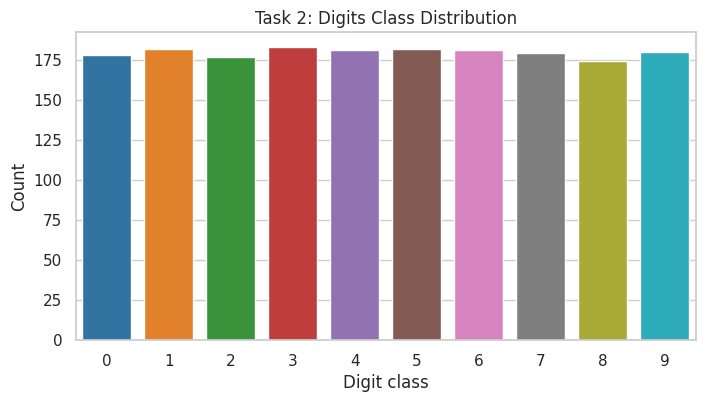

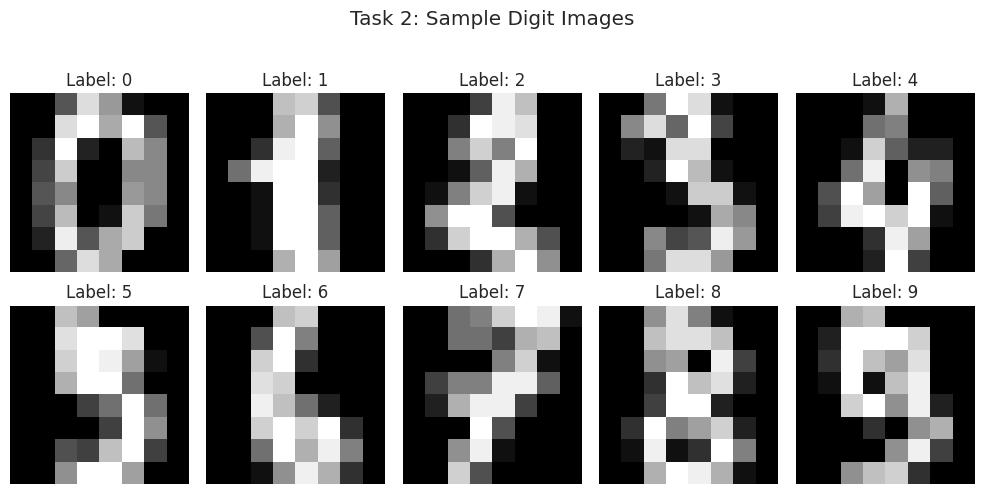

,Model,Accuracy,Train Time (s)
0,OvR,0.975000,0.178699
1,OvO,0.980556,0.123109



Hint: Compare number of classifiers too -> OvR: 10, OvO: 45


In [11]:
# Task 2 Starter Code (50 pts)

# TODO 1: Load more-class dataset
digits = load_digits()
X_d, y_d = digits.data, digits.target


# --- Visualization block (to understand Digits before training) ---
# 1) Class distribution for digits 0-9
plt.figure(figsize=(8, 4))
sns.countplot(x=y_d, palette="tab10")
plt.title("Task 2: Digits Class Distribution")
plt.xlabel("Digit class")
plt.ylabel("Count")
plt.show()

# 2) Show sample images (first 10 examples)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {y_d[i]}")
    ax.axis("off")
plt.suptitle("Task 2: Sample Digit Images", y=1.02)
plt.tight_layout()
plt.show()

# TODO 2: Split the dataset
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)


# TODO 3: Standardize features
scaler_d = StandardScaler()
X_d_train_scaled = scaler_d.fit_transform(X_d_train)  # fit on train only
X_d_test_scaled  = scaler_d.transform(X_d_test)

# TODO 4: Train OvR and record time
start_ovr_d = time.perf_counter()
#your code
ovr_d = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
ovr_d.fit(X_d_train_scaled, y_d_train)
ovr_d_time = time.perf_counter() - start_ovr_d

# TODO 5: Train OvO and record time
start_ovo_d = time.perf_counter()
ovo_d = OneVsOneClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
ovo_d.fit(X_d_train_scaled, y_d_train)
#your code
ovo_d_time = time.perf_counter() - start_ovo_d

# TODO 6: Evaluate
pred_ovr_d =ovr_d.predict(X_d_test_scaled)
pred_ovo_d =ovo_d.predict(X_d_test_scaled)

results_digits = pd.DataFrame({
    "Model": ["OvR", "OvO"],
    "Accuracy": [accuracy_score(y_d_test, pred_ovr_d), accuracy_score(y_d_test, pred_ovo_d)],
    "Train Time (s)": [ovr_d_time, ovo_d_time]
})

display(results_digits)
print("\nHint: Compare number of classifiers too -> OvR: 10, OvO: 45")


## 4) Question Section – 10pts

###  Q1 (3.3%)
Compare computational complexity of OvA and OvO as the number of classes \(K\) increases.  
Discuss both training-time and inference-time implications.

**Answer Box:**  

---

###  Q2 (3.3%)
Describe one realistic scenario where OvA is preferred and one where OvO is preferred.  
Justify your choices using class structure and deployment constraints.

**Answer Box:**  


---

###  Q3 (3.4%)
How do class imbalance and non-linear class boundaries limit logistic regression in multi-class settings?  
Suggest at least two mitigation strategies.

**Answer Box:**  
